In [1]:
import torch

from DataLoader import DataLoaderProprietary
from DataViewModel import LoadedDataViewModel

device = "cuda" if torch.cuda.is_available() else "cpu"
    
loaded_data_view_model : LoadedDataViewModel = DataLoaderProprietary.load_all_data(
    load_from_csv_files=False, 
    file_name='final_dataset_nove_vozidla_2', 
    load_video_annotations=True)


SensorNormalizer: ignore_rfid = False , use_left_right_arm_info = True , field_names = None
Bola spustena inicializacia dat
Celkovy pocet data messages : 0
Celkovy pocet vysypov: 0
split b les between car arms
remove bad les
Spustam nacitanie dat
Spúšťam načítanie loaded data viewmodelu
Nacitanie dokoncene


In [2]:
LoadedDataViewModel.add_dummy_messages(loaded_data_view_model.vehicles)

Pridavam dummy messages
Hotovo


In [3]:
import DataViewModel
import WindowedLeBasedDataset
import importlib
importlib.reload(WindowedLeBasedDataset)
import SensorNormalizer
importlib.reload(SensorNormalizer)

vehicle_split_commands = []
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA196JN_video'))
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA234JG_video'))
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA503JU_video'))
#vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA127IR'))
#vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA234JG'))
#vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA255KC'))
#vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA346KA'))
#vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, 'ZA499JN'))




loaded_data_view_model.normalizer = SensorNormalizer.SensorNormalizer(
    True, 
    False,   
    ["axis_x_acc",  #Akcelerometer – zrýchlenie na osi X
    "axis_y_acc",  #Akcelerometer – zrýchlenie na osi Y
    "axis_z_acc",  #Akcelerometer – zrýchlenie na osi Z
    "sig_pwr"] ) # radar 

if False:
    

    train_vehicles_ecv = ['ZA127IR', 'ZA234JG',  'ZA255KC', 'ZA346KA', 'ZA499JN']
    train_vehicles = []
    for vehicle in loaded_data_view_model.train_vehicles:
        if vehicle.ecv in train_vehicles_ecv:
            train_vehicles.append(vehicle)
    

loaded_data_view_model.split_to_train_and_test(vehicle_split_commands)




SensorNormalizer: ignore_rfid = True , use_left_right_arm_info = False , field_names = ['axis_x_acc', 'axis_y_acc', 'axis_z_acc', 'sig_pwr']
Vozidlo s ecv: ZA127IR bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA234JG bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA255KC bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA346KA bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA499JN bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: AA619SP bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: AA713KN bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT155HT bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT874HR bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT752GY bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT769GY bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA196JN_video bolo zaradene do testovacej mnoziny
Vozidlo s ecv: ZA234JG_video bolo zaradene do testovacej mnoziny
Vozidlo s ecv: ZA503JU_video bolo zaradene do testovacej mnoziny
Normalizer para

In [4]:
train_dataset = WindowedLeBasedDataset.WindowedLeBasedDataset(loaded_data_view_model.train_vehicles, 25 * 2, 'train', 25)
test_dataset = WindowedLeBasedDataset.WindowedLeBasedDataset(loaded_data_view_model.test_vehicles, 25 * 2, 'test', 25)

Zostavenie datasetu pre train mnozinu
ZA127IR
ZA234JG
ZA255KC
ZA346KA
ZA499JN
AA619SP
AA713KN
BT155HT
BT874HR
BT752GY
BT769GY
Dataset vytvoreny
Zostavenie datasetu pre test mnozinu
ZA196JN_video
ZA234JG_video
ZA503JU_video
Dataset vytvoreny


In [5]:

patience = 50
train = False

import TrainingRadar
import Networks
import importlib
importlib.reload(TrainingRadar)
importlib.reload(Networks)

# Finálne parametre z grid search
FINAL_DROPOUT = 0.2
FINAL_WEIGHT_DECAY = 1e-3
FINAL_B1_MULTIPLIER = 3.0
FINAL_B2_MULTIPLIER = 5.0

# Pôvodná sieť (rollback)
model = Networks.CnnBaseNetworkRadar(10, 4, 50, dropout_rate=FINAL_DROPOUT)

print(
    f"Final training (Base CNN) | dropout={FINAL_DROPOUT}, weight_decay={FINAL_WEIGHT_DECAY}, "
    f"B1x={FINAL_B1_MULTIPLIER}, B2x={FINAL_B2_MULTIPLIER}"
)

trainer = TrainingRadar.TrainingRadar(
    model,
    'container_type_le_based_best',
    1000,
    lr=3e-4,
    weight_decay=FINAL_WEIGHT_DECAY,
    device='cuda',
    class_weight_b1_multiplier=FINAL_B1_MULTIPLIER,
    class_weight_b2_multiplier=FINAL_B2_MULTIPLIER,
)

training_results = trainer.train(train_dataset, test_dataset, 4, train, patience, ['L', 'R', 'B1', 'B2'])
model = training_results["model"]


Final training (Base CNN) | dropout=0.2, weight_decay=0.001, B1x=3.0, B2x=5.0


In [6]:
sample, label = train_dataset[0]
print(label)
print(type(label))
print(label.shape if torch.is_tensor(label) else "not tensor")

tensor([1., 0., 0., 0.])
<class 'torch.Tensor'>
torch.Size([4])


Raw label: tensor([1., 0., 0., 0.])
True class: 0
Plot shape: torch.Size([10, 50])
Predicted class: 0
Confidence: 0.9635
All probabilities: [0.9634756  0.00594648 0.00255594 0.02802199]


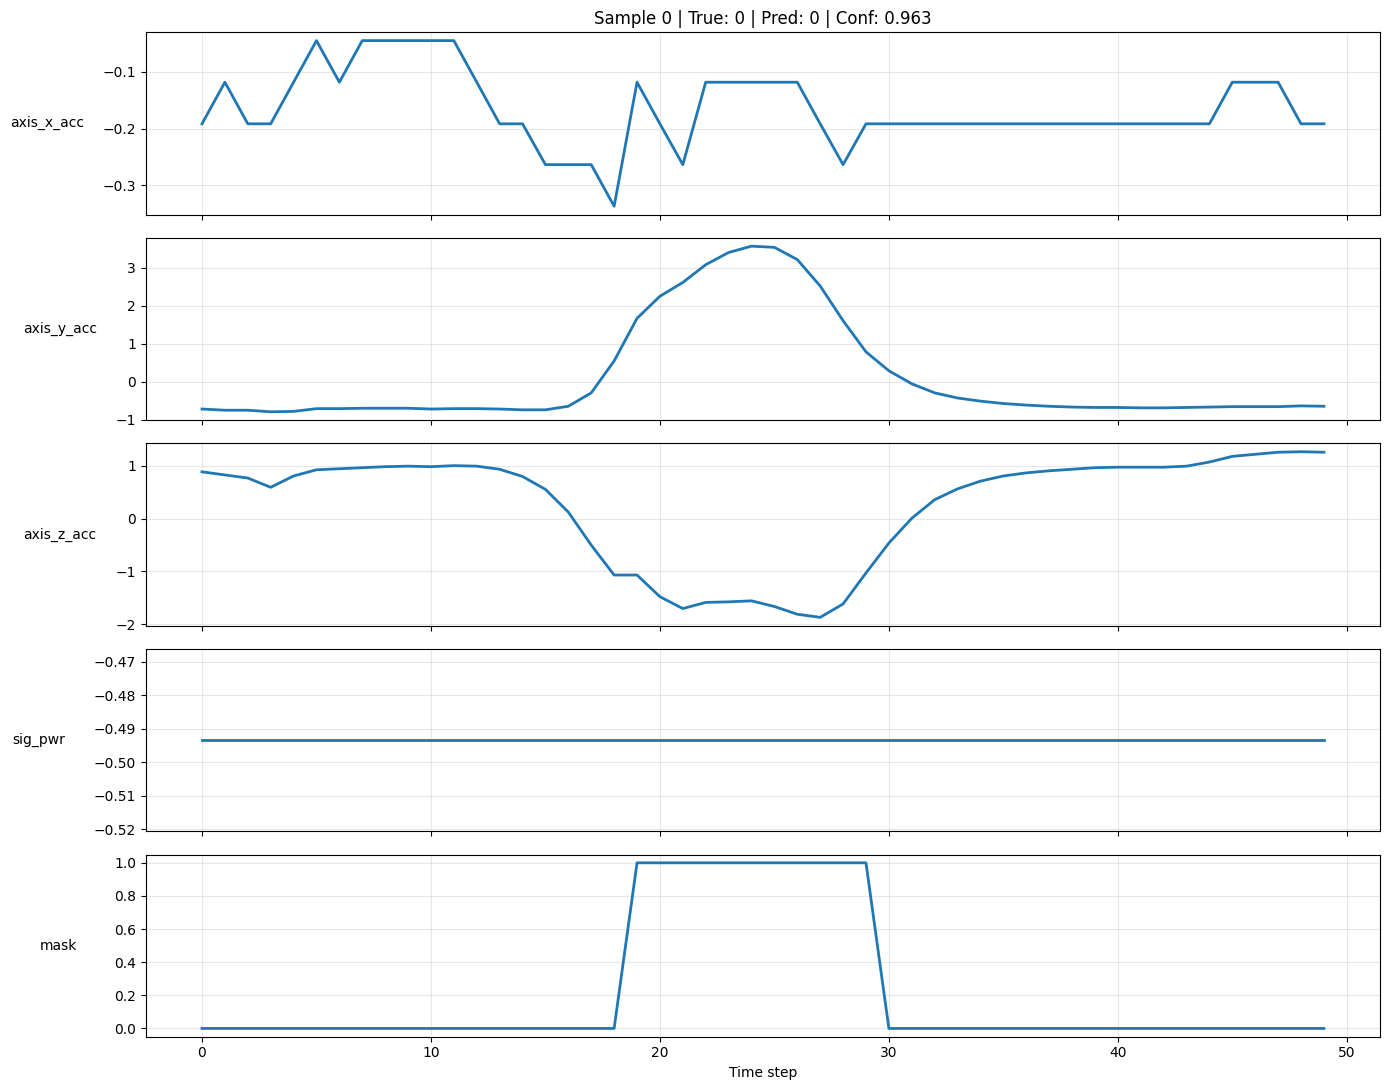

In [7]:
import matplotlib.pyplot as plt

sample, label = train_dataset[0]

# --- spracovanie true labelu ---
raw_label = label

if torch.is_tensor(label):
    if label.numel() == 1:
        true_label = label.item()
    else:
        true_label = torch.argmax(label).item()
else:
    true_label = label

print("Raw label:", raw_label)
print("True class:", true_label)

# --- príprava sample pre plot ---
plot_sample = sample.detach().cpu()

# chceme shape [num_features, time]
if plot_sample.shape[0] > plot_sample.shape[1]:
    plot_sample = plot_sample.T

print("Plot shape:", plot_sample.shape)

# --- inference modelu ---
device = next(model.parameters()).device
input_tensor = sample.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_class].item()

print("Predicted class:", pred_class)
print("Confidence:", round(confidence, 4))
print("All probabilities:", probs[0].detach().cpu().numpy())

# --- názvy feature ---
feature_names = ["axis_x_acc", "axis_y_acc", "axis_z_acc", "sig_pwr", "mask"]
num_features = min(plot_sample.shape[0], len(feature_names))

# --- vykreslenie nad sebou ---
fig, axes = plt.subplots(num_features, 1, figsize=(14, 2.2 * num_features), sharex=True)

if num_features == 1:
    axes = [axes]

for i in range(num_features):
    axes[i].plot(plot_sample[i].numpy(), linewidth=2)
    axes[i].set_ylabel(feature_names[i], rotation=0, labelpad=40, va="center")
    axes[i].grid(True, alpha=0.3)

axes[0].set_title(
    f"Sample 0 | True: {true_label} | Pred: {pred_class} | Conf: {confidence:.3f}"
)
axes[-1].set_xlabel("Time step")

plt.tight_layout()
plt.show()

In [8]:
import importlib
import Visualizer
importlib.reload(Visualizer)
import torch

class_names = ['L', 'R', 'B1', 'B2']
errors_by_class = {class_name: None for class_name in class_names}

i = 0
visualize_count = 4  # jeden z každej kategórie

for vehicle in loaded_data_view_model.test_vehicles:  # len testovacia množina
    if vehicle.ecv not in test_dataset.windows_by_vehicle:
        continue

    for window in test_dataset.windows_by_vehicle[vehicle.ecv]:
        if i >= visualize_count:
            break

        result = model(window.tensor_input.unsqueeze(0).to(device))
        logits = torch.softmax(result, dim=1)
        model_pred = torch.argmax(logits, dim=1).item()
        ground_truth = window.result_class

        if model_pred != ground_truth:
            class_name = class_names[ground_truth]

            if errors_by_class[class_name] is None:
                errors_by_class[class_name] = (vehicle, window, logits)
                print(f"Chyba v kategórii {class_name}: {vehicle.ecv} - model predpovedá {class_names[model_pred]}")
                Visualizer.Visualizer.visualize_window(window, logits)
                i += 1

    if i >= visualize_count:
        break

NameError: name 'LitteringCandidate' is not defined